# Klaszterezés (csoportosítás)

A [klaszterezés során](https://hu.wikipedia.org/wiki/Klaszteranal%C3%ADzis) egy adathalmaz pontjait, objektumait hasonlóság alapján csoportosítjuk, úgy hogy az egy csoportban lévő objektumok minél inkább egymáshoz hasonlóak, míg a más csoportokban lévők pedig különbözőek legyenek.

![](https://bookdown.org/tpinto_home/Unsupervised-learning/kmeans.png)

Ábra 1. Klaszterezés példa. [Forrás](https://bookdown.org/tpinto_home/Unsupervised-learning/k-means-clustering.html).


# Példa

https://machinelearningmastery.com/clustering-algorithms-with-python/

Szintetikus adatok generálása:


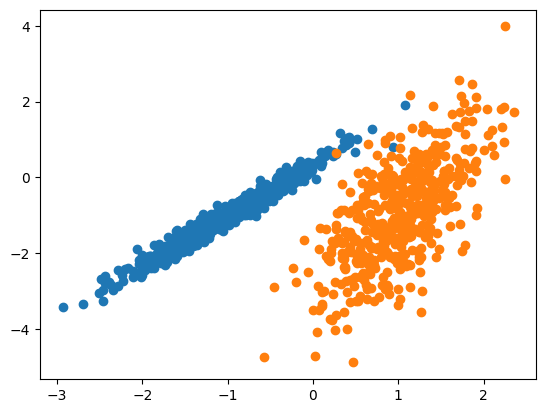

In [ ]:
# Szintetikus adatok generálása
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification
from matplotlib import pyplot

X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=4)

for class_value in range(2):
	row_ix = where(y == class_value)
	pyplot.scatter(X[row_ix, 0], X[row_ix, 1])

pyplot.show()

In [ ]:
def show_clusters(clusters, X, y):
  for cluster in clusters:
    row_ix = where(y == cluster)
    pyplot.scatter(X[row_ix, 0], X[row_ix, 1])
  pyplot.show()

## [Affinity Propagation Clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AffinityPropagation.html)

In [ ]:
# Affinity propagation klaszterezés
from sklearn.cluster import AffinityPropagation

# Model létrehozása
model = AffinityPropagation(damping=0.5)
# Model tanítása
model.fit(X)
# Klaszterek előrejelzése
y = model.predict(X)
# Klaszterek azonosítása
clusters = unique(y)

show_clusters(clusters, X, y)

## [Agglomerative Clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=2)
y = model.fit_predict(X)
clusters = unique(y)

show_clusters(clusters, X, y)

## [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

In [ ]:
# k-means clustering
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2)
model.fit(X)
y = model.predict(X)
clusters = unique(y)
show_clusters(clusters, X, y)

## [BIRCH](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.Birch.html?highlight=birch)

In [ ]:
from sklearn.cluster import Birch

model = Birch(threshold=0.01, n_clusters=2)
model.fit(X)
y = model.predict(X)
clusters = unique(y)
show_clusters(clusters, X, y)

## [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

In [ ]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.30, min_samples=9)
y = model.fit_predict(X)
clusters = unique(y)
show_clusters(clusters, X, y)

[Stb.](https://machinelearningmastery.com/clustering-algorithms-with-python/)

# Feladatok


1. K-means algoritmus segítségével klaszterezzük a következő ponthalmazokat:
```python
from sklearn.datasets import make_blobs, make_moons 
X1, y_true1 = make_blobs(n_samples=500, centers=5, cluster_std=0.55, random_state=42) 
X2, y_true2 = make_moons(200, noise=.05, random_state=42)
```

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons

X1, y_true1 = make_blobs(n_samples=500, centers=5, cluster_std=0.55, random_state=42)
X2, y_true2 = make_moons(200, noise=.05, random_state=42)

...

2. Elemezzük hogyan viselkedik a módszer különböző `K` paraméterek esetében, illetve ismételt futtatás esetében (különböző `random_state` értékek).

3. Miért észlelünk javulást, ha a második ponthalmaz esetében `SpectralClustering` módszerrel és legközelebbi szomszéd affinitással klaszterezünk?
```python
from sklearn.cluster import SpectralClustering 
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans') 
labels = model.fit_predict(X2) 
plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=50, cmap='viridis');
```

4. Klaszterezzük a [„The Digit Dataset”](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html) számjegy adathalmazt:
```python
from sklearn.datasets import load_digits 
digits = load_digits()
```

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

...

5. Mérjük meg, hogy a klaszterezés (felügyelet nélküli tanulás) mennyire volt sikeres az adatokban lévő hasonló számok csoportosításában. A számjegyek helyes címkézését a következő utasítássorozattal kaphatjuk meg:
```python
from scipy.stats import mode 
labels = np.zeros_like(clusters) 
for i in range(10): 
    mask = (clusters == i) 
    labels[mask] = mode(digits.target[mask])[0]
```

6. A konfuziós mátrix segítségével, vizsgáljuk meg, hogy a klaszterezés melyik számjegyeket csoportosítja helytelenül a legtöbbször.